AVISO LEGAL — PROPIEDAD INTELECTUAL

Este material es propiedad intelectual exclusiva de Julián David Flórez Sánchez (LinkedIn). Todos los derechos reservados. Queda terminantemente prohibida su copia, reproducción, distribución, adaptación o uso por cualquier persona natural o jurídica, pública o privada, sin autorización expresa y escrita del autor. El incumplimiento de esta disposición acarrea las sanciones civiles y penales previstas en la Ley 23 de 1982, la Decisión Andina 351 de 1993, los artículos 270-272 del Código Penal Colombiano y los tratados internacionales de propiedad intelectual aplicables. Para solicitar autorización: linkedin.com/in/julianflorezdata

# Guia 08: Transicion a PyTorch - Fundamentos

## Electiva II - Deep Learning | Tecnologico de Antioquia

---

**Objetivo:** Aprender los fundamentos de PyTorch y poder construir, entrenar y evaluar redes neuronales con este framework. Los estudiantes realizaran la transicion desde TensorFlow/Keras hacia PyTorch, que sera el framework principal para el resto del curso.

**Conceptos nuevos en esta guia:**
- Tensores en PyTorch y su relacion con NumPy
- Autograd: diferenciacion automatica
- `nn.Module`: la clase base para construir modelos
- `Dataset` y `DataLoader`: carga y procesamiento de datos
- Ciclo de entrenamiento manual (forward -> loss -> backward -> step -> zero_grad)
- `torch.optim`: optimizadores en PyTorch
- Comparacion detallada Keras vs PyTorch

**Prerrequisito:** Guia 07 completada

**Duracion estimada:** 3 horas

**GPU:** Asegurate de activar el entorno con GPU en Colab: `Entorno de ejecucion` -> `Cambiar tipo de entorno de ejecucion` -> `GPU (T4)`

---

### Aviso importante sobre evaluacion

Las celdas marcadas con el icono de escritura representan preguntas evaluables. Debes responderlas de forma individual y con tus propias palabras. Estas respuestas seran revisadas como parte de la evaluacion continua del curso.

---

## 1. Configuracion del entorno

PyTorch ya viene preinstalado en Google Colab, pero vamos a verificarlo e instalar/actualizar si es necesario.

In [ ]:
# Verificar si PyTorch esta instalado; si no, instalarlo
try:
    import torch
    print(f'PyTorch ya esta instalado. Version: {torch.__version__}')
except ImportError:
    print('Instalando PyTorch...')
    !pip install torch torchvision -q
    import torch
    print(f'PyTorch instalado. Version: {torch.__version__}')

PyTorch ya esta instalado. Version: 2.10.0+cu128


In [ ]:
# Importar todas las librerias necesarias
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt
import time
import copy

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configuracion de graficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print('Todas las librerias importadas correctamente.')

Todas las librerias importadas correctamente.


In [ ]:
# Verificar disponibilidad de GPU
if torch.cuda.is_available():
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
    print(f'Memoria GPU total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA version: {torch.version.cuda}')
else:
    print('GPU NO disponible. Usando CPU.')
    print('IMPORTANTE: Activa la GPU en Colab para mejor rendimiento.')
    print('Menu: Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU')

# Definir el dispositivo que usaremos en todo el notebook
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDispositivo seleccionado: {device}')

GPU disponible: Tesla T4
Memoria GPU total: 15.6 GB
CUDA version: 12.8

Dispositivo seleccionado: cuda


---

## 2. Marco teorico: De Keras a PyTorch

### 2.1 ¿Por que aprender PyTorch si ya sabemos Keras?

Hasta ahora hemos trabajado exclusivamente con TensorFlow/Keras, un framework excelente para aprender deep learning por su simplicidad. Sin embargo, hay razones muy importantes para aprender PyTorch:

1. **Dominio en investigacion:** PyTorch es el framework mas usado en papers academicos y conferencias como NeurIPS, ICML y ICLR. Si quieres leer, reproducir o contribuir a investigacion en deep learning, necesitas PyTorch.

2. **Crecimiento en industria:** Empresas como Meta, Tesla, OpenAI y Microsoft usan PyTorch. Su adopcion en produccion ha crecido enormemente.

3. **Flexibilidad y control:** PyTorch te da control total sobre cada paso del entrenamiento. Esto es esencial cuando necesitas implementar arquitecturas personalizadas, funciones de perdida no estandar, o esquemas de entrenamiento complejos.

4. **Es "pythonico":** PyTorch se siente como Python puro. El codigo es mas natural y facil de depurar porque usa ejecucion inmediata por defecto.

5. **Hugging Face Transformers:** La libreria mas importante para NLP y modelos de lenguaje (que veremos en guias futuras) usa PyTorch como backend por defecto.

6. **Empleabilidad:** Saber ambos frameworks te convierte en un profesional mas versatil y competitivo en el mercado laboral.

### 2.2 Comparacion detallada: Keras vs PyTorch

| Aspecto | Keras (TensorFlow) | PyTorch |
|---------|-------------------|----------|
| **Filosofia** | Alto nivel, facil de usar | Bajo nivel, flexible |
| **Ejecucion** | Graph mode (compilado) | Eager mode (inmediato) |
| **Definir modelo** | `Sequential` o API funcional | Clase que hereda de `nn.Module` |
| **Compilar** | `model.compile(loss, optimizer)` | No se compila; defines loss y optimizer por separado |
| **Entrenar** | `model.fit(X, y, epochs)` | Loop manual: forward, loss, backward, step |
| **Evaluar** | `model.evaluate(X_test, y_test)` | Loop manual con `torch.no_grad()` |
| **GPU** | Automatica (si hay GPU disponible) | Manual: `tensor.to(device)`, `model.to(device)` |
| **Depuracion** | Mas dificil (grafo compilado) | Mas facil (puedes usar print, pdb) |
| **Gradientes** | Ocultos (los maneja Keras) | Explicitos (tu controlas `backward()`) |
| **Guardar modelo** | `model.save('modelo.h5')` | `torch.save(model.state_dict(), 'modelo.pth')` |
| **Comunidad** | Mas tutoriales para principiantes | Mas papers y codigo de investigacion |
| **Curva de aprendizaje** | Mas suave | Mas empinada, pero mas formativa |

### 2.3 Tensores en PyTorch

Los **tensores** son la estructura de datos fundamental en PyTorch. Son similares a los arrays de NumPy, pero con dos superpoderes adicionales:

1. **Pueden ejecutarse en GPU:** Acelerando enormemente los calculos con matrices grandes.
2. **Soportan diferenciacion automatica:** PyTorch puede calcular gradientes automaticamente, lo cual es esencial para entrenar redes neuronales.

```python
# NumPy                          # PyTorch
x = np.array([1, 2, 3])         x = torch.tensor([1, 2, 3])
x.shape                          x.shape
x.dtype                          x.dtype
x + y                            x + y
np.dot(x, y)                     torch.matmul(x, y)
x.reshape(3, 1)                  x.reshape(3, 1)  # o x.view(3, 1)
```

### 2.4 Autograd: Diferenciacion automatica

En Keras, cuando entrenas con `model.fit()`, los gradientes se calculan automaticamente "detras de escena". En PyTorch, tienes acceso directo a este mecanismo llamado **autograd**.

El concepto clave: cuando creas un tensor con `requires_grad=True`, PyTorch registra todas las operaciones que se hacen con ese tensor. Luego, al llamar `.backward()`, calcula los gradientes automaticamente usando la **regla de la cadena** (chain rule).

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial w}$$

Esto es exactamente lo que hace el **backpropagation** que estudiamos en la Guia 01, pero automatizado.

### 2.5 nn.Module: Construir modelos en PyTorch

En Keras defines modelos asi:

```python
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
```

En PyTorch, creas una **clase** que hereda de `nn.Module`:

```python
class MiModelo(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
```

Dos metodos esenciales:
- `__init__`: Define las capas (equivalente a listar capas en Sequential)
- `forward`: Define como fluyen los datos a traves de las capas (esto en Keras es automatico)

### 2.6 Dataset y DataLoader

En Keras, simplemente pasas arrays NumPy a `model.fit()` y Keras se encarga del batching.

En PyTorch, usas dos abstracciones:
- **Dataset:** Define de donde vienen los datos y como acceder a cada ejemplo.
- **DataLoader:** Envuelve un Dataset para crear mini-batches, mezclar datos (shuffle) y cargar datos en paralelo.

```python
# Crear DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Iterar sobre mini-batches
for images, labels in train_loader:
    # images tiene shape [64, 1, 28, 28]
    # labels tiene shape [64]
    ...
```

### 2.7 El ciclo de entrenamiento manual

Esta es la diferencia mas grande entre Keras y PyTorch. En Keras:

```python
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=64)
```

En PyTorch, tu escribes cada paso:

```python
for epoch in range(num_epochs):
    for batch_x, batch_y in train_loader:
        # 1. Forward pass: pasar datos por el modelo
        outputs = model(batch_x)
        
        # 2. Calcular la perdida
        loss = criterion(outputs, batch_y)
        
        # 3. Backward pass: calcular gradientes
        loss.backward()
        
        # 4. Actualizar pesos
        optimizer.step()
        
        # 5. Limpiar gradientes para el siguiente batch
        optimizer.zero_grad()
```

¿Por que esto es una **ventaja**? Porque puedes:
- Modificar el loss durante el entrenamiento
- Implementar gradient clipping, gradient accumulation
- Entrenar con multiples losses o multiples modelos
- Agregar logica condicional en medio del entrenamiento
- Depurar cada paso individualmente

---

## 3. Carga y preparacion de datos: Fashion-MNIST

Usaremos el **mismo dataset** que en la Guia 03 (Fashion-MNIST) para poder comparar resultados directamente entre Keras y PyTorch.

En torchvision, los datasets se descargan con transformaciones aplicadas automaticamente.

In [ ]:
# Definir las transformaciones para los datos
# ToTensor() convierte imagenes o arrays numpy a tensores PyTorch
# y escala los valores de [0, 255] a [0.0, 1.0]
# Normalize() aplica normalizacion con media y desviacion estandar
transform = transforms.Compose([
    transforms.ToTensor(),  # Convierte a tensor y escala a [0, 1]
    transforms.Normalize((0.5,), (0.5,))  # Normaliza a [-1, 1]: (valor - 0.5) / 0.5
])

# Descargar Fashion-MNIST
# train=True para el conjunto de entrenamiento (60,000 imagenes)
# train=False para el conjunto de prueba (10,000 imagenes)
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f'Tamano del conjunto de entrenamiento: {len(train_dataset)}')
print(f'Tamano del conjunto de prueba: {len(test_dataset)}')
print(f'Forma de una imagen: {train_dataset[0][0].shape}')
print(f'Tipo de dato: {train_dataset[0][0].dtype}')

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.40MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.2MB/s]

Tamano del conjunto de entrenamiento: 60000
Tamano del conjunto de prueba: 10000
Forma de una imagen: torch.Size([1, 28, 28])
Tipo de dato: torch.float32


In [ ]:
# Crear DataLoaders para manejar los mini-batches
# batch_size=64: cada batch tendra 64 imagenes
# shuffle=True en entrenamiento: mezclar datos cada epoca
# shuffle=False en prueba: no es necesario mezclar
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,  # Cargar datos en paralelo
    pin_memory=True  # Optimizacion para transferencia CPU -> GPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Verificar un batch
images, labels = next(iter(train_loader))
print(f'Forma de un batch de imagenes: {images.shape}')  # [64, 1, 28, 28]
print(f'Forma de un batch de etiquetas: {labels.shape}')  # [64]
print(f'Numero de batches en entrenamiento: {len(train_loader)}')
print(f'Numero de batches en prueba: {len(test_loader)}')

Forma de un batch de imagenes: torch.Size([64, 1, 28, 28])
Forma de un batch de etiquetas: torch.Size([64])
Numero de batches en entrenamiento: 938
Numero de batches en prueba: 157


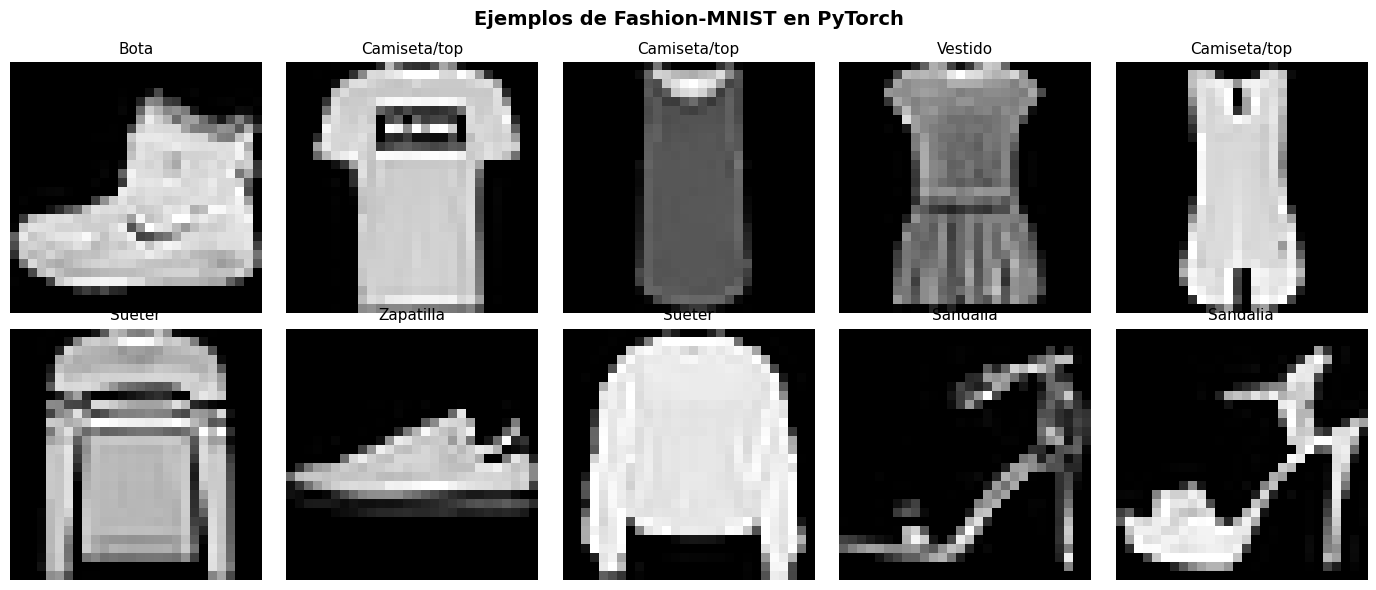

In [ ]:
# Nombres de las clases de Fashion-MNIST
class_names = ['Camiseta/top', 'Pantalon', 'Sueter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']

# Visualizar algunos ejemplos del dataset
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    # Obtener imagen y etiqueta
    img, label = train_dataset[i]

    # Desnormalizar para visualizar: de [-1, 1] a [0, 1]
    img = img * 0.5 + 0.5

    # Mostrar imagen (squeeze para quitar el canal)
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'{class_names[label]}', fontsize=11)
    ax.axis('off')

plt.suptitle('Ejemplos de Fashion-MNIST en PyTorch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

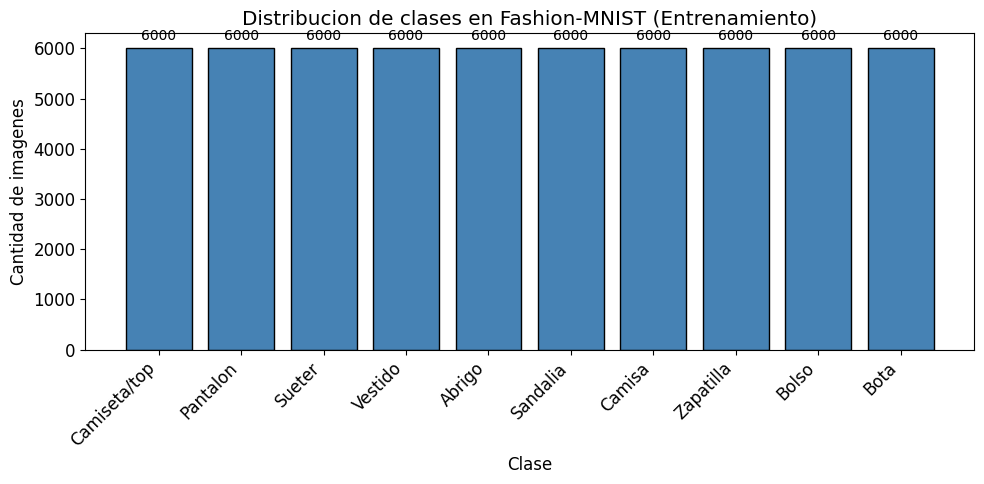


El dataset esta balanceado: cada clase tiene 6000 imagenes.


In [ ]:
# Distribucion de clases en el conjunto de entrenamiento
# Accedemos directamente a las etiquetas del dataset
train_labels = train_dataset.targets.numpy()

fig, ax = plt.subplots(figsize=(10, 5))
unique, counts = np.unique(train_labels, return_counts=True)
bars = ax.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Clase')
ax.set_ylabel('Cantidad de imagenes')
ax.set_title('Distribucion de clases en Fashion-MNIST (Entrenamiento)')
plt.xticks(rotation=45, ha='right')

# Agregar valores sobre las barras
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{count}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nEl dataset esta balanceado: cada clase tiene {counts[0]} imagenes.')

---

## 4. Experimentacion guiada

### Experimento 1: Tensores en PyTorch

Los tensores son la piedra angular de PyTorch. Vamos a explorar como crearlos, manipularlos y aprovechar la GPU para acelerar calculos.

In [ ]:
# ========================================
# 1.1 Crear tensores de diferentes formas
# ========================================

# Desde una lista de Python
tensor_lista = torch.tensor([1, 2, 3, 4, 5])
print(f'Desde lista: {tensor_lista}')
print(f'  Tipo: {tensor_lista.dtype}, Forma: {tensor_lista.shape}')

# Desde una lista 2D (matriz)
tensor_matriz = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(f'\nMatriz 2D: \n{tensor_matriz}')
print(f'  Tipo: {tensor_matriz.dtype}, Forma: {tensor_matriz.shape}')

# Tensor de ceros
tensor_ceros = torch.zeros(3, 4)
print(f'\nCeros (3x4): \n{tensor_ceros}')

# Tensor de unos
tensor_unos = torch.ones(2, 3)
print(f'\nUnos (2x3): \n{tensor_unos}')

# Tensor aleatorio (distribucion uniforme [0, 1))
tensor_rand = torch.rand(3, 3)
print(f'\nAleatorio uniforme (3x3): \n{tensor_rand}')

# Tensor aleatorio (distribucion normal)
tensor_randn = torch.randn(3, 3)
print(f'\nAleatorio normal (3x3): \n{tensor_randn}')

# Tensor con un rango de valores
tensor_rango = torch.arange(0, 10, 2)
print(f'\nRango (0 a 10, paso 2): {tensor_rango}')

# Tensor con valores espaciados linealmente
tensor_linspace = torch.linspace(0, 1, 5)
print(f'\nLinspace (0 a 1, 5 puntos): {tensor_linspace}')

# Matriz identidad
tensor_eye = torch.eye(4)
print(f'\nIdentidad (4x4): \n{tensor_eye}')

Desde lista: tensor([1, 2, 3, 4, 5])
  Tipo: torch.int64, Forma: torch.Size([5])

Matriz 2D: 
tensor([[1, 2, 3],
        [4, 5, 6]])
  Tipo: torch.int64, Forma: torch.Size([2, 3])

Ceros (3x4): 
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Unos (2x3): 
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Aleatorio uniforme (3x3): 
tensor([[0.3904, 0.6009, 0.2566],
        [0.7936, 0.9408, 0.1332],
        [0.9346, 0.5936, 0.8694]])

Aleatorio normal (3x3): 
tensor([[-1.0324, -0.2770, -0.1671],
        [-0.1079, -1.4285, -0.2810],
        [ 0.7489,  1.1164,  1.2931]])

Rango (0 a 10, paso 2): tensor([0, 2, 4, 6, 8])

Linspace (0 a 1, 5 puntos): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

Identidad (4x4): 
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


In [ ]:
# ========================================
# 1.2 Operaciones basicas con tensores
# ========================================

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

# Suma
print(f'Suma: {a + b}')           # o torch.add(a, b)

# Resta
print(f'Resta: {a - b}')          # o torch.sub(a, b)

# Multiplicacion elemento a elemento
print(f'Multiplicacion: {a * b}') # o torch.mul(a, b)

# Division
print(f'Division: {a / b}')       # o torch.div(a, b)

# Producto punto
print(f'Producto punto: {torch.dot(a, b)}')

# Potencia
print(f'Potencia: {a ** 2}')      # o torch.pow(a, 2)

# Operaciones de reduccion
print(f'\nSuma total: {a.sum()}')
print(f'Media: {a.mean()}')
print(f'Maximo: {a.max()}')
print(f'Minimo: {a.min()}')
print(f'Desviacion estandar: {a.std()}')

# Reshape y View
c = torch.arange(12)
print(f'\nOriginal: {c}, Forma: {c.shape}')
print(f'Reshape (3x4): \n{c.reshape(3, 4)}')
print(f'View (4x3): \n{c.view(4, 3)}')
print(f'View (2x2x3): \n{c.view(2, 2, 3)}')

# Slicing (igual que NumPy)
d = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(f'\nMatriz completa: \n{d}')
print(f'Primera fila: {d[0]}')
print(f'Primera columna: {d[:, 0]}')
print(f'Submatriz (2x2 superior izq): \n{d[:2, :2]}')

Suma: tensor([5., 7., 9.])
Resta: tensor([-3., -3., -3.])
Multiplicacion: tensor([ 4., 10., 18.])
Division: tensor([0.2500, 0.4000, 0.5000])
Producto punto: 32.0
Potencia: tensor([1., 4., 9.])

Suma total: 6.0
Media: 2.0
Maximo: 3.0
Minimo: 1.0
Desviacion estandar: 1.0

Original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), Forma: torch.Size([12])
Reshape (3x4): 
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
View (4x3): 
tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])
View (2x2x3): 
tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]]])

Matriz completa: 
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Primera fila: tensor([1, 2, 3])
Primera columna: tensor([1, 4, 7])
Submatriz (2x2 superior izq): 
tensor([[1, 2],
        [4, 5]])


In [ ]:
# ========================================
# 1.3 Conversion NumPy <-> PyTorch
# ========================================

# NumPy a PyTorch
array_np = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
tensor_from_np = torch.from_numpy(array_np)
print(f'Array NumPy: {array_np}')
print(f'Tensor PyTorch: {tensor_from_np}')
print(f'Tipo: {tensor_from_np.dtype}')

# CUIDADO: comparten memoria! Cambiar uno cambia el otro
array_np[0] = 999
print(f'\nDespues de cambiar array_np[0] = 999:')
print(f'Array NumPy: {array_np}')
print(f'Tensor PyTorch: {tensor_from_np}')  # Tambien cambio!

# Para evitar esto, usar .clone()
array_np2 = np.array([10.0, 20.0, 30.0])
tensor_copia = torch.from_numpy(array_np2).clone()
array_np2[0] = 0
print(f'\nCon .clone() - Array: {array_np2}, Tensor: {tensor_copia}')  # Independientes

# PyTorch a NumPy
tensor_pt = torch.tensor([10.0, 20.0, 30.0])
array_from_pt = tensor_pt.numpy()
print(f'\nTensor PyTorch: {tensor_pt}')
print(f'Array NumPy: {array_from_pt}')

# Si el tensor esta en GPU, primero hay que moverlo a CPU
# tensor_gpu.cpu().numpy()  # Esto seria necesario si el tensor esta en GPU

Array NumPy: [1. 2. 3. 4. 5.]
Tensor PyTorch: tensor([1., 2., 3., 4., 5.], dtype=torch.float64)
Tipo: torch.float64

Despues de cambiar array_np[0] = 999:
Array NumPy: [999.   2.   3.   4.   5.]
Tensor PyTorch: tensor([999.,   2.,   3.,   4.,   5.], dtype=torch.float64)

Con .clone() - Array: [ 0. 20. 30.], Tensor: tensor([10., 20., 30.], dtype=torch.float64)

Tensor PyTorch: tensor([10., 20., 30.])
Array NumPy: [10. 20. 30.]


In [ ]:
# ========================================
# 1.4 Mover tensores a GPU
# ========================================

# Crear un tensor en CPU
tensor_cpu = torch.rand(3, 3)
print(f'Tensor en: {tensor_cpu.device}')

# Mover a GPU (si esta disponible)
tensor_gpu = tensor_cpu.to(device)
print(f'Tensor movido a: {tensor_gpu.device}')

# Tambien se puede crear directamente en GPU
if torch.cuda.is_available():
    tensor_directo_gpu = torch.rand(3, 3, device='cuda')
    print(f'Tensor creado directamente en: {tensor_directo_gpu.device}')

# IMPORTANTE: No puedes mezclar tensores en CPU y GPU
# tensor_cpu + tensor_gpu  # Esto daria ERROR
# Solucion: mover ambos al mismo dispositivo
resultado = tensor_cpu.to(device) + tensor_gpu
print(f'\nSuma (ambos en {device}): \n{resultado}')

Tensor en: cpu
Tensor movido a: cuda:0
Tensor creado directamente en: cuda:0

Suma (ambos en cuda): 
tensor([[1.1664, 0.6753, 1.6179],
        [1.1559, 1.8080, 1.1093],
        [0.6846, 1.2687, 0.7288]], device='cuda:0')


In [ ]:
# ========================================
# 1.5 Comparar velocidad CPU vs GPU
# ========================================

# Multiplicacion de matrices grandes
tamano = 5000

# --- En CPU ---
a_cpu = torch.rand(tamano, tamano)
b_cpu = torch.rand(tamano, tamano)

inicio_cpu = time.time()
c_cpu = torch.matmul(a_cpu, b_cpu)
tiempo_cpu = time.time() - inicio_cpu
print(f'Multiplicacion de matrices {tamano}x{tamano} en CPU: {tiempo_cpu:.4f} segundos')

# --- En GPU ---
if torch.cuda.is_available():
    a_gpu = a_cpu.to('cuda')
    b_gpu = b_cpu.to('cuda')

    # Calentar la GPU (la primera operacion suele ser mas lenta)
    _ = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()  # Esperar a que termine la GPU

    inicio_gpu = time.time()
    c_gpu = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()  # Asegurar que la operacion termino
    tiempo_gpu = time.time() - inicio_gpu

    print(f'Multiplicacion de matrices {tamano}x{tamano} en GPU: {tiempo_gpu:.4f} segundos')
    print(f'\nLa GPU fue {tiempo_cpu / tiempo_gpu:.1f}x mas rapida que la CPU!')

    # Verificar que los resultados son iguales
    diferencia = torch.abs(c_cpu - c_gpu.cpu()).max().item()
    print(f'Diferencia maxima entre CPU y GPU: {diSferencia:.6f} (errores de precision flotante)')
else:
    print('GPU no disponible para comparar. Activa la GPU en Colab.')

Multiplicacion de matrices 5000x5000 en CPU: 1.9425 segundos
Multiplicacion de matrices 5000x5000 en GPU: 0.0880 segundos

La GPU fue 22.1x mas rapida que la CPU!
Diferencia maxima entre CPU y GPU: 0.007935 (errores de precision flotante)


### Tu respuesta - Experimento 1

**Pregunta:** ¿Cuanto mas rapida fue la GPU vs la CPU en la multiplicacion de matrices? ¿Que operaciones crees que se benefician mas de la GPU?

*22.1 veces más rapida y pues la multiplicación de matrices*

---

### Experimento 2: Autograd - Diferenciacion automatica

La **diferenciacion automatica** es el motor que permite entrenar redes neuronales. En PyTorch, este sistema se llama **autograd** y nos permite calcular gradientes automaticamente.

Recordemos que el entrenamiento de una red neuronal requiere calcular:

$$\frac{\partial \mathcal{L}}{\partial w_i}$$

Es decir, como cambia la funcion de perdida $\mathcal{L}$ con respecto a cada peso $w_i$. Con autograd, PyTorch construye un **grafo computacional** que registra todas las operaciones y luego usa la **regla de la cadena** para calcular estos gradientes automaticamente.

In [ ]:
# ========================================
# 2.1 Gradientes de una funcion simple
# ========================================

# Crear un tensor con requires_grad=True para rastrear operaciones
x = torch.tensor(2.0, requires_grad=True)
print(f'x = {x}')
print(f'requires_grad = {x.requires_grad}')

# Definir una funcion: y = x^2 + 3x + 1
y = x**2 + 3*x + 1
print(f'\ny = x^2 + 3x + 1')
print(f'y = {y}')

# Calcular el gradiente: dy/dx = 2x + 3
y.backward()

# El gradiente se almacena en x.grad
print(f'\nGradiente calculado por autograd: dy/dx = {x.grad}')

# Verificacion manual: dy/dx = 2(2) + 3 = 7
print(f'Verificacion manual: dy/dx = 2({x.item()}) + 3 = {2*x.item() + 3}')
print(f'¿Coinciden? {x.grad.item() == 2*x.item() + 3}')

x = 2.0
requires_grad = True

y = x^2 + 3x + 1
y = 11.0

Gradiente calculado por autograd: dy/dx = 7.0
Verificacion manual: dy/dx = 2(2.0) + 3 = 7.0
¿Coinciden? True


In [ ]:
# ========================================
# 2.2 Gradientes con multiples variables
# ========================================

# Funcion de dos variables: f(a, b) = a^2 * b + b^3
a = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(4.0, requires_grad=True)

# Calcular f
f = a**2 * b + b**3
print(f'f(a={a.item()}, b={b.item()}) = a^2 * b + b^3 = {f.item()}')

# Calcular gradientes
f.backward()

# df/da = 2ab
print(f'\ndf/da (autograd) = {a.grad.item()}')
print(f'df/da (manual) = 2*a*b = 2*{a.item()}*{b.item()} = {2*a.item()*b.item()}')

# df/db = a^2 + 3b^2
print(f'\ndf/db (autograd) = {b.grad.item()}')
print(f'df/db (manual) = a^2 + 3*b^2 = {a.item()}^2 + 3*{b.item()}^2 = {a.item()**2 + 3*b.item()**2}')

f(a=3.0, b=4.0) = a^2 * b + b^3 = 100.0

df/da (autograd) = 24.0
df/da (manual) = 2*a*b = 2*3.0*4.0 = 24.0

df/db (autograd) = 57.0
df/db (manual) = a^2 + 3*b^2 = 3.0^2 + 3*4.0^2 = 57.0


Parametros aprendidos: w = 1.9971, bias = 0.8933
Valores reales:        w = 2.0000, bias = 1.0000


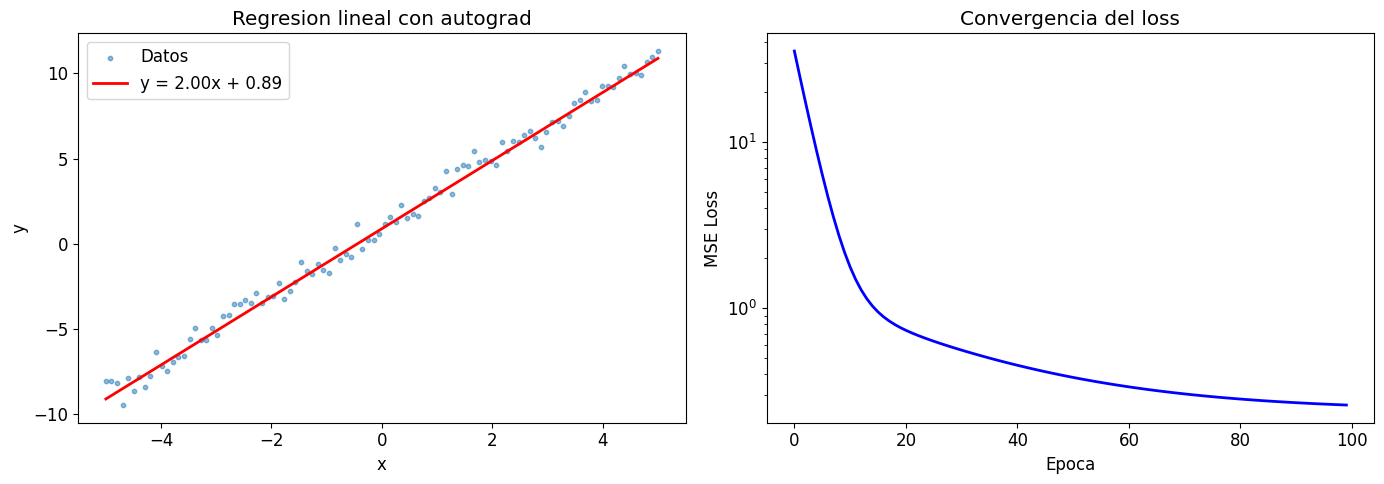

In [ ]:
# ========================================
# 2.3 Ejemplo practico: regresion lineal simple con autograd
# ========================================

# Datos sinteticos: y = 2x + 1 + ruido
torch.manual_seed(42)
X_simple = torch.linspace(-5, 5, 100)
y_simple = 2 * X_simple + 1 + torch.randn(100) * 0.5

# Parametros a aprender (inicializados aleatoriamente)
w = torch.tensor(0.0, requires_grad=True)  # peso
bias = torch.tensor(0.0, requires_grad=True)  # sesgo

lr = 0.01  # tasa de aprendizaje
num_epochs = 100
historial_loss = []

for epoch in range(num_epochs):
    # Forward: prediccion
    y_pred = w * X_simple + bias

    # Calcular MSE loss
    loss = ((y_pred - y_simple) ** 2).mean()
    historial_loss.append(loss.item())

    # Backward: calcular gradientes
    loss.backward()

    # Actualizar parametros manualmente (sin optimizador)
    with torch.no_grad():  # No rastrear estas operaciones
        w -= lr * w.grad
        bias -= lr * bias.grad

    # Limpiar gradientes
    w.grad.zero_()
    bias.grad.zero_()

print(f'Parametros aprendidos: w = {w.item():.4f}, bias = {bias.item():.4f}')
print(f'Valores reales:        w = 2.0000, bias = 1.0000')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de datos y recta ajustada
axes[0].scatter(X_simple.numpy(), y_simple.numpy(), alpha=0.5, s=10, label='Datos')
with torch.no_grad():
    y_linea = w * X_simple + bias
axes[0].plot(X_simple.numpy(), y_linea.numpy(), 'r-', linewidth=2,
             label=f'y = {w.item():.2f}x + {bias.item():.2f}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Regresion lineal con autograd')
axes[0].legend()

# Grafico de loss
axes[1].plot(historial_loss, 'b-', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Convergencia del loss')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# ========================================
# 2.4 torch.no_grad() para inferencia
# ========================================

x = torch.tensor(5.0, requires_grad=True)

# Con gradientes (modo entrenamiento)
y = x ** 2
print(f'Con gradientes: y = {y}, requires_grad = {y.requires_grad}')

# Sin gradientes (modo inferencia)
# Util para: predicciones, evaluacion, ahorra memoria
with torch.no_grad():
    y_no_grad = x ** 2
    print(f'Sin gradientes: y = {y_no_grad}, requires_grad = {y_no_grad.requires_grad}')

print('\ntorch.no_grad() es ESENCIAL durante la evaluacion e inferencia.')
print('Razones:')
print('1. Ahorra memoria (no almacena el grafo computacional)')
print('2. Acelera los calculos')
print('3. Evita modificar gradientes accidentalmente')

Con gradientes: y = 25.0, requires_grad = True
Sin gradientes: y = 25.0, requires_grad = False

torch.no_grad() es ESENCIAL durante la evaluacion e inferencia.
Razones:
1. Ahorra memoria (no almacena el grafo computacional)
2. Acelera los calculos
3. Evita modificar gradientes accidentalmente


### Tu respuesta - Experimento 2

**Pregunta:** ¿Por que es importante la diferenciacion automatica para entrenar redes neuronales? ¿Que relacion tiene con backpropagation?

*es una función esencial para la etapa de evaluación o inferencia, ya que desactiva el rastreo de gradientes para optimizar el rendimiento. Al usarlo, el sistema deja de guardar información para el entrenamiento, lo que permite ahorrar memoria, hacer los cálculos más rápido y garantizar que no se modifiquen los parámetros del modelo por error.*

---

### Experimento 3: Tu primera red neuronal en PyTorch (nn.Module)

Ahora vamos a construir una red neuronal real usando `nn.Module`. Usaremos la **misma arquitectura** que en la Guia 02 (784 -> 128 -> 64 -> 10) para poder comparar directamente con Keras.

Recordemos como se definia en Keras:
```python
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
```

Ahora veamos como se hace en PyTorch:

In [ ]:
# ========================================
# 3.1 Definir la red neuronal con nn.Module
# ========================================

class MiRed(nn.Module):
    """
    Red neuronal fully-connected para clasificacion de Fashion-MNIST.
    Arquitectura: 784 -> 128 -> 64 -> 10
    (Misma que la Guia 02 en Keras)
    """

    def __init__(self):
        # Llamar al constructor de nn.Module (OBLIGATORIO)
        super(MiRed, self).__init__()

        # Definir las capas
        # nn.Linear es el equivalente de keras.layers.Dense
        # nn.Linear(entrada, salida) -> y = Wx + b
        self.fc1 = nn.Linear(784, 128)   # Primera capa: 784 entradas, 128 salidas
        self.fc2 = nn.Linear(128, 64)    # Segunda capa: 128 entradas, 64 salidas
        self.fc3 = nn.Linear(64, 10)     # Capa de salida: 64 entradas, 10 salidas

    def forward(self, x):
        """
        Define como los datos fluyen a traves de la red.
        En Keras esto es automatico; en PyTorch lo definimos explicitamente.
        """
        # Aplanar la imagen de [batch, 1, 28, 28] a [batch, 784]
        x = x.view(x.size(0), -1)  # Equivalente a keras.layers.Flatten()

        # Primera capa + activacion ReLU
        x = F.relu(self.fc1(x))

        # Segunda capa + activacion ReLU
        x = F.relu(self.fc2(x))

        # Capa de salida (SIN softmax)
        x = self.fc3(x)

        return x

# Instanciar el modelo
model = MiRed()

# Mover el modelo a GPU
model = model.to(device)

print('Arquitectura del modelo:')
print(model)
print(f'\nDispositivo del modelo: {next(model.parameters()).device}')

Arquitectura del modelo:
MiRed(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

Dispositivo del modelo: cuda:0


**Nota importante:** En PyTorch, la capa de salida **no tiene softmax**. ¿Por que?

Porque `nn.CrossEntropyLoss()` (que usaremos como funcion de perdida) ya incluye internamente un `LogSoftmax` + `NLLLoss`. Esto es mas estable numericamente que aplicar softmax por separado.

| Keras | PyTorch |
|-------|----------|
| `Dense(10, activation='softmax')` + `CategoricalCrossentropy` | `Linear(64, 10)` (sin softmax) + `CrossEntropyLoss` |
| Softmax explicito en el modelo | Softmax implicito en el loss |

In [ ]:
# ========================================
# 3.2 Explorar los parametros del modelo
# ========================================

# Ver todos los parametros (pesos y biases)
print('Parametros del modelo:\n')
for nombre, parametro in model.named_parameters():
    print(f'{nombre}:')
    print(f'  Forma: {parametro.shape}')
    print(f'  Numero de parametros: {parametro.numel()}')
    print(f'  Requiere gradiente: {parametro.requires_grad}')
    print()

Parametros del modelo:

fc1.weight:
  Forma: torch.Size([128, 784])
  Numero de parametros: 100352
  Requiere gradiente: True

fc1.bias:
  Forma: torch.Size([128])
  Numero de parametros: 128
  Requiere gradiente: True

fc2.weight:
  Forma: torch.Size([64, 128])
  Numero de parametros: 8192
  Requiere gradiente: True

fc2.bias:
  Forma: torch.Size([64])
  Numero de parametros: 64
  Requiere gradiente: True

fc3.weight:
  Forma: torch.Size([10, 64])
  Numero de parametros: 640
  Requiere gradiente: True

fc3.bias:
  Forma: torch.Size([10])
  Numero de parametros: 10
  Requiere gradiente: True



In [ ]:
# ========================================
# 3.3 Contar parametros totales
# ========================================

# Funcion para contar parametros (util en cualquier modelo)
def contar_parametros(modelo):
    """Cuenta el numero total de parametros entrenables en un modelo."""
    total = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total

total_params = contar_parametros(model)
print(f'Numero total de parametros entrenables: {total_params:,}')

# Desglose manual:
# fc1: 784*128 + 128 = 100,480
# fc2: 128*64 + 64 = 8,256
# fc3: 64*10 + 10 = 650
# Total: 109,386
print(f'\nDesglose:')
print(f'  fc1 (784x128 + 128): {784*128 + 128:,}')
print(f'  fc2 (128x64 + 64):   {128*64 + 64:,}')
print(f'  fc3 (64x10 + 10):    {64*10 + 10:,}')
print(f'  Total:               {784*128 + 128 + 128*64 + 64 + 64*10 + 10:,}')

Numero total de parametros entrenables: 109,386

Desglose:
  fc1 (784x128 + 128): 100,480
  fc2 (128x64 + 64):   8,256
  fc3 (64x10 + 10):    650
  Total:               109,386


In [ ]:
# ========================================
# 3.4 Probar el modelo con un batch de ejemplo
# ========================================

# Obtener un batch de datos
images_ejemplo, labels_ejemplo = next(iter(train_loader))
images_ejemplo = images_ejemplo.to(device)

# Pasar por el modelo (forward pass)
with torch.no_grad():
    salida = model(images_ejemplo)

print(f'Forma de entrada: {images_ejemplo.shape}')  # [64, 1, 28, 28]
print(f'Forma de salida:  {salida.shape}')           # [64, 10]
print(f'\nSalida para la primera imagen (logits, sin softmax):')
print(f'  {salida[0]}')

# Aplicar softmax para obtener probabilidades
probabilidades = F.softmax(salida[0], dim=0)
print(f'\nProbabilidades (con softmax):')
for i, prob in enumerate(probabilidades):
    print(f'  {class_names[i]}: {prob.item():.4f}')

# Prediccion (clase con mayor probabilidad)
prediccion = torch.argmax(salida[0]).item()
print(f'\nPrediccion: {class_names[prediccion]}')
print(f'Etiqueta real: {class_names[labels_ejemplo[0].item()]}')
print('\n(El modelo aun no esta entrenado, asi que la prediccion es aleatoria)')

Forma de entrada: torch.Size([64, 1, 28, 28])
Forma de salida:  torch.Size([64, 10])

Salida para la primera imagen (logits, sin softmax):
  tensor([ 0.0059, -0.1233,  0.0012,  0.0227,  0.0631, -0.1276, -0.0728, -0.0311,
         0.0423, -0.0124], device='cuda:0')

Probabilidades (con softmax):
  Camiseta/top: 0.1028
  Pantalon: 0.0903
  Sueter: 0.1023
  Vestido: 0.1045
  Abrigo: 0.1088
  Sandalia: 0.0899
  Camisa: 0.0950
  Zapatilla: 0.0990
  Bolso: 0.1066
  Bota: 0.1009

Prediccion: Abrigo
Etiqueta real: Camisa

(El modelo aun no esta entrenado, asi que la prediccion es aleatoria)


### Tu respuesta - Experimento 3

**Pregunta:** ¿En que se parece y se diferencia definir un modelo en PyTorch vs Keras? ¿Cual te parece mas claro?

*PyTorch es manual y Keras automático; en PyTorch programas tú mismo el flujo de datos, Mientras Keras es más claro por su sencillez, PyTorch ofrece control total sobre la lógica interna del modelo. Esta transparencia lo hace ideal para personalizar y entender qué ocurre exactamente "bajo el capó".*

---

### Experimento 4: El ciclo de entrenamiento completo

Este es el experimento mas importante de la guia. Vamos a escribir el **ciclo de entrenamiento completo** de PyTorch, paso a paso.

Recordemos la comparacion:

| Paso | Keras | PyTorch |
|------|-------|----------|
| 1. Definir loss | `model.compile(loss=...)` | `criterion = nn.CrossEntropyLoss()` |
| 2. Definir optimizador | `model.compile(optimizer=...)` | `optimizer = optim.Adam(model.parameters())` |
| 3. Entrenar | `model.fit(X, y, epochs)` | Loop manual con forward, backward, step |
| 4. Evaluar | `model.evaluate(X_test, y_test)` | Loop manual con `torch.no_grad()` |

In [ ]:
# ========================================
# 4.1 Definir modelo, loss y optimizador
# ========================================

# Crear un modelo nuevo (fresco, sin entrenar)
model = MiRed().to(device)

# Definir la funcion de perdida
# CrossEntropyLoss combina LogSoftmax + NLLLoss
# Equivalente a categorical_crossentropy en Keras
criterion = nn.CrossEntropyLoss()

# Definir el optimizador
# Le pasamos los parametros del modelo para que sepa que actualizar
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('Modelo, loss y optimizador definidos.')
print(f'  Loss: {criterion}')
print(f'  Optimizador: Adam con lr=0.001')
print(f'  Parametros: {contar_parametros(model):,}')

Modelo, loss y optimizador definidos.
  Loss: CrossEntropyLoss()
  Optimizador: Adam con lr=0.001
  Parametros: 109,386


In [ ]:
# ========================================
# 4.2 Funcion de entrenamiento por una epoca
# ========================================

def entrenar_una_epoca(model, train_loader, criterion, optimizer, device):
    """
    Entrena el modelo por una epoca completa.
    Retorna el loss promedio y la accuracy de la epoca.
    """
    model.train()  # Activar modo entrenamiento

    total_loss = 0.0
    total_correctos = 0
    total_muestras = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Mover datos a GPU
        images = images.to(device)
        labels = labels.to(device)

        # ---- PASO 1: Forward pass ----
        # Pasar los datos por el modelo para obtener predicciones
        outputs = model(images)

        # ---- PASO 2: Calcular la perdida ----
        loss = criterion(outputs, labels)

        # ---- PASO 3: Backward pass ----
        # Calcular los gradientes de todos los parametros
        loss.backward()

        # ---- PASO 4: Actualizar pesos ----
        # El optimizador ajusta los pesos usando los gradientes
        optimizer.step()

        # ---- PASO 5: Limpiar gradientes ----
        # MUY IMPORTANTE: PyTorch acumula gradientes por defecto
        # Si no los limpiamos, se sumarian con los del siguiente batch
        optimizer.zero_grad()

        # Acumular metricas
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_correctos += (predicted == labels).sum().item()
        total_muestras += images.size(0)

    # Calcular metricas promedio de la epoca
    avg_loss = total_loss / total_muestras
    accuracy = total_correctos / total_muestras

    return avg_loss, accuracy

In [ ]:
# ========================================
# 4.3 Funcion de evaluacion
# ========================================

def evaluar(model, data_loader, criterion, device):
    """
    Evalua el modelo en un conjunto de datos.
    Retorna el loss promedio y la accuracy.
    """
    model.eval()  # Activar modo evaluacion

    total_loss = 0.0
    total_correctos = 0
    total_muestras = 0

    # torch.no_grad(): no calcular gradientes (ahorra memoria y es mas rapido)
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Solo forward pass, sin backward
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_correctos += (predicted == labels).sum().item()
            total_muestras += images.size(0)

    avg_loss = total_loss / total_muestras
    accuracy = total_correctos / total_muestras

    return avg_loss, accuracy

In [ ]:
# ========================================
# 4.4 Ciclo de entrenamiento completo
# ========================================

# Hiperparametros
NUM_EPOCHS = 15

# Historial para graficar
historial = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print('Iniciando entrenamiento...')
print('=' * 70)

tiempo_inicio = time.time()

for epoch in range(NUM_EPOCHS):
    epoca_inicio = time.time()

    # Entrenar una epoca
    train_loss, train_acc = entrenar_una_epoca(
        model, train_loader, criterion, optimizer, device
    )

    # Evaluar en conjunto de prueba (como validacion)
    val_loss, val_acc = evaluar(
        model, test_loader, criterion, device
    )

    # Guardar en historial
    historial['train_loss'].append(train_loss)
    historial['train_acc'].append(train_acc)
    historial['val_loss'].append(val_loss)
    historial['val_acc'].append(val_acc)

    epoca_tiempo = time.time() - epoca_inicio

    # Imprimir progreso
    print(f'Epoca [{epoch+1:2d}/{NUM_EPOCHS}] '
          f'| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} '
          f'| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} '
          f'| Tiempo: {epoca_tiempo:.1f}s')

tiempo_total = time.time() - tiempo_inicio
print('=' * 70)
print(f'Entrenamiento completado en {tiempo_total:.1f} segundos')
print(f'Mejor accuracy en validacion: {max(historial["val_acc"]):.4f}')

Iniciando entrenamiento...
Epoca [ 1/15] | Train Loss: 0.5223 | Train Acc: 0.8134 | Val Loss: 0.4326 | Val Acc: 0.8436 | Tiempo: 16.6s
Epoca [ 2/15] | Train Loss: 0.3811 | Train Acc: 0.8597 | Val Loss: 0.4097 | Val Acc: 0.8538 | Tiempo: 15.5s
Epoca [ 3/15] | Train Loss: 0.3407 | Train Acc: 0.8755 | Val Loss: 0.4186 | Val Acc: 0.8370 | Tiempo: 20.1s
Epoca [ 4/15] | Train Loss: 0.3214 | Train Acc: 0.8800 | Val Loss: 0.3749 | Val Acc: 0.8670 | Tiempo: 16.5s
Epoca [ 5/15] | Train Loss: 0.2983 | Train Acc: 0.8895 | Val Loss: 0.3491 | Val Acc: 0.8727 | Tiempo: 17.8s
Epoca [ 6/15] | Train Loss: 0.2819 | Train Acc: 0.8948 | Val Loss: 0.3589 | Val Acc: 0.8730 | Tiempo: 18.2s
Epoca [ 7/15] | Train Loss: 0.2722 | Train Acc: 0.8992 | Val Loss: 0.3564 | Val Acc: 0.8746 | Tiempo: 16.5s
Epoca [ 8/15] | Train Loss: 0.2606 | Train Acc: 0.9030 | Val Loss: 0.3490 | Val Acc: 0.8761 | Tiempo: 15.8s
Epoca [ 9/15] | Train Loss: 0.2457 | Train Acc: 0.9081 | Val Loss: 0.3789 | Val Acc: 0.8696 | Tiempo: 16.3s
E

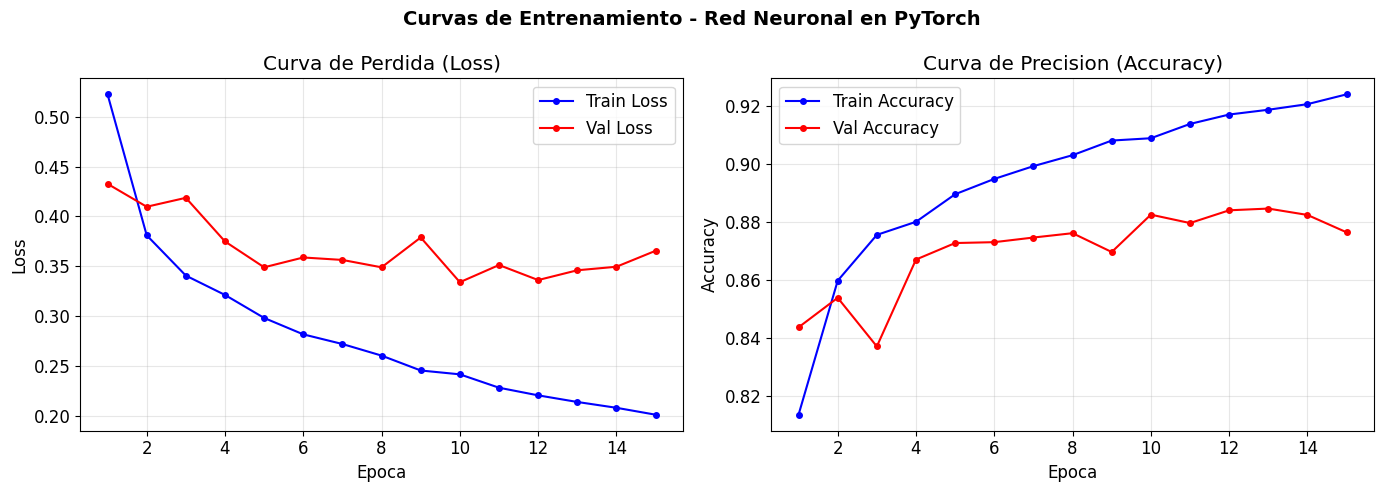

In [ ]:
# ========================================
# 4.5 Graficar curvas de entrenamiento
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de Loss
axes[0].plot(range(1, NUM_EPOCHS+1), historial['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(range(1, NUM_EPOCHS+1), historial['val_loss'], 'r-o', label='Val Loss', markersize=4)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Perdida (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafico de Accuracy
axes[1].plot(range(1, NUM_EPOCHS+1), historial['train_acc'], 'b-o', label='Train Accuracy', markersize=4)
axes[1].plot(range(1, NUM_EPOCHS+1), historial['val_acc'], 'r-o', label='Val Accuracy', markersize=4)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de Precision (Accuracy)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento - Red Neuronal en PyTorch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Tu respuesta - Experimento 4

**Pregunta:** ¿Por que es necesario llamar `optimizer.zero_grad()`? ¿Que pasaria si lo olvidaras?

*Es necesario llamar a optimizer.zero_grad() porque PyTorch, por defecto, acumula los gradientes en cada paso del entrenamiento. Si olvidaras incluirlo, los gradientes del lote actual se sumarían a los del lote anterior, provocando que el modelo intente actualizar sus pesos basándose en información acumulada incorrecta en lugar de solo los datos nuevos. Esto causaría que el entrenamiento no converja o que el modelo se comporte de manera errática al aplicar ajustes distorsionados.*

---

### Experimento 5: Evaluar el modelo entrenado

Ahora vamos a evaluar nuestro modelo de forma mas detallada, incluyendo predicciones visuales y la matriz de confusion.

In [ ]:
# ========================================
# 5.1 Evaluacion final en el conjunto de prueba
# ========================================

# Poner el modelo en modo evaluacion
model.eval()

# Evaluar
test_loss, test_acc = evaluar(model, test_loader, criterion, device)
print(f'Resultados en conjunto de prueba:')
print(f'  Loss: {test_loss:.4f}')
print(f'  Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'\nComparacion: En la Guia 03 con Keras, la misma arquitectura')
print(f'obtenia un accuracy similar (~87-89% dependiendo de la ejecucion).')

Resultados en conjunto de prueba:
  Loss: 0.3656
  Accuracy: 0.8764 (87.64%)

Comparacion: En la Guia 03 con Keras, la misma arquitectura
obtenia un accuracy similar (~87-89% dependiendo de la ejecucion).


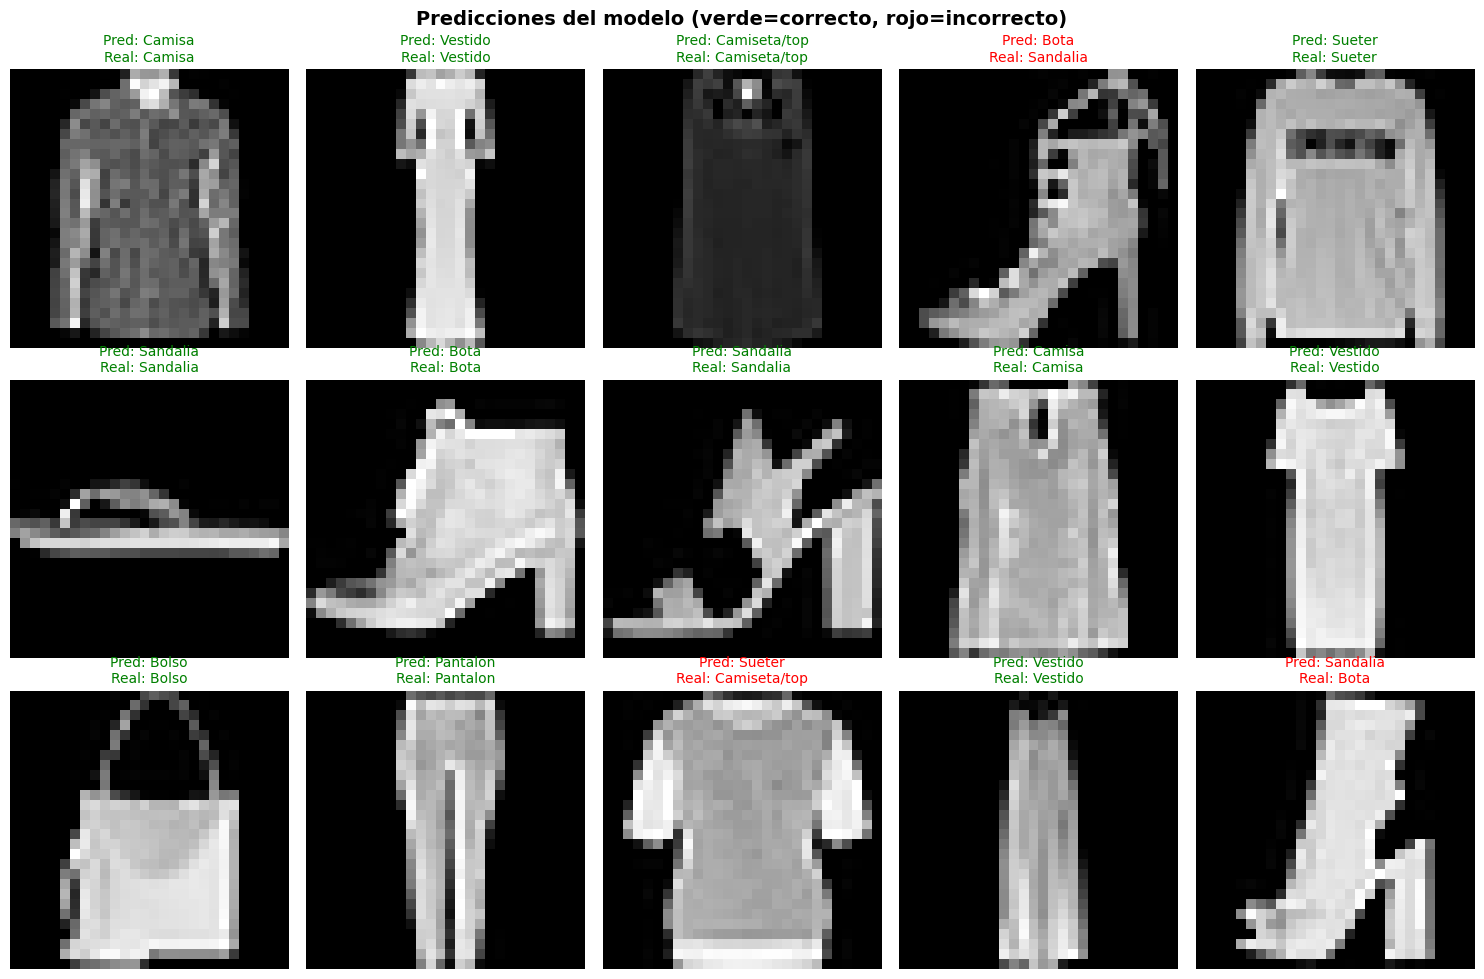

In [ ]:
# ========================================
# 5.2 Visualizar predicciones individuales
# ========================================

# Obtener predicciones para todo el conjunto de prueba
todas_predicciones = []
todas_etiquetas = []
todas_imagenes = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        todas_predicciones.extend(predicted.cpu().numpy())
        todas_etiquetas.extend(labels.numpy())
        todas_imagenes.extend(images.cpu())

todas_predicciones = np.array(todas_predicciones)
todas_etiquetas = np.array(todas_etiquetas)

# Mostrar 15 predicciones aleatorias
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
indices = np.random.choice(len(todas_etiquetas), 15, replace=False)

for i, (ax, idx) in enumerate(zip(axes.flat, indices)):
    img = todas_imagenes[idx].squeeze() * 0.5 + 0.5  # Desnormalizar
    pred = todas_predicciones[idx]
    real = todas_etiquetas[idx]

    ax.imshow(img.numpy(), cmap='gray')

    # Verde si es correcto, rojo si es incorrecto
    color = 'green' if pred == real else 'red'
    ax.set_title(f'Pred: {class_names[pred]}\nReal: {class_names[real]}',
                color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Predicciones del modelo (verde=correcto, rojo=incorrecto)',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

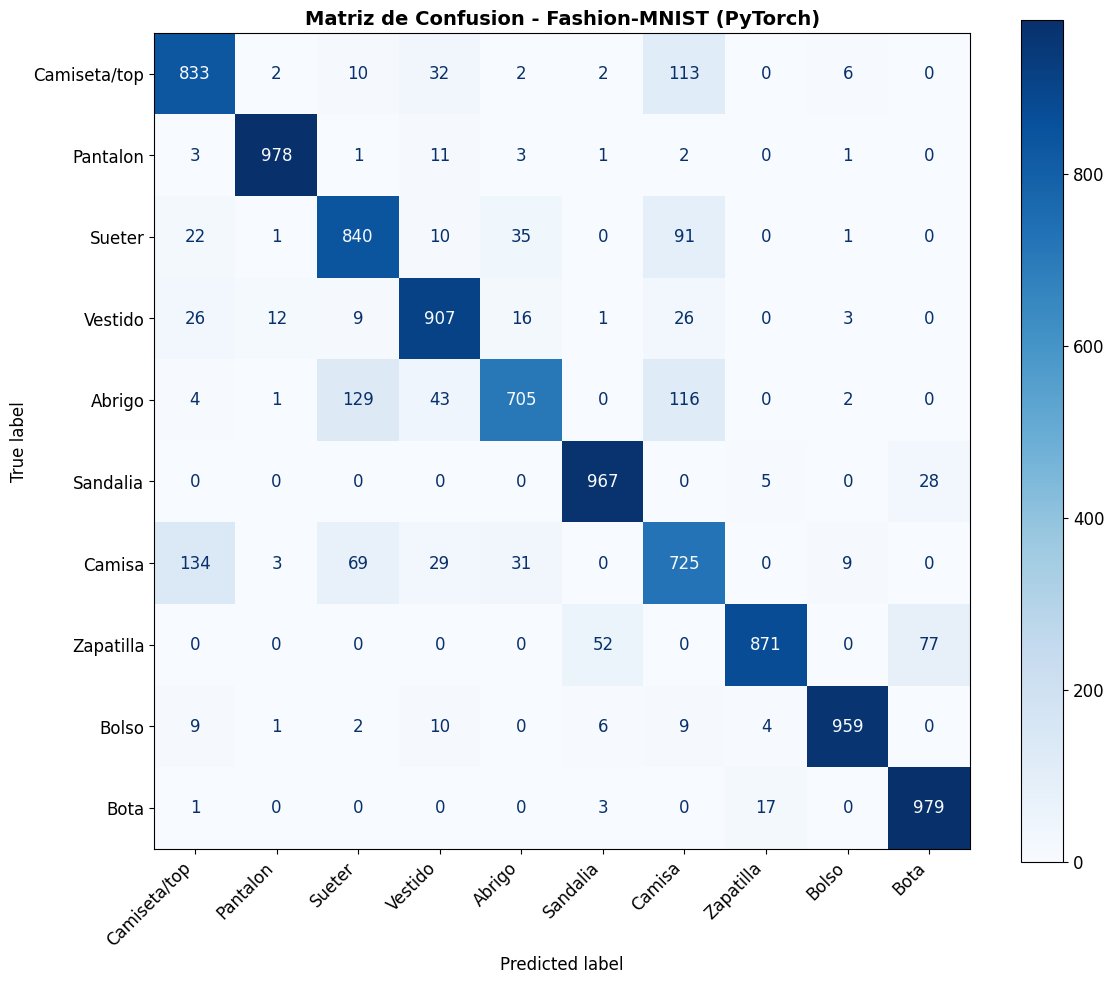


Reporte de clasificacion detallado:

              precision    recall  f1-score   support

Camiseta/top       0.81      0.83      0.82      1000
    Pantalon       0.98      0.98      0.98      1000
      Sueter       0.79      0.84      0.82      1000
     Vestido       0.87      0.91      0.89      1000
      Abrigo       0.89      0.70      0.79      1000
    Sandalia       0.94      0.97      0.95      1000
      Camisa       0.67      0.72      0.70      1000
   Zapatilla       0.97      0.87      0.92      1000
       Bolso       0.98      0.96      0.97      1000
        Bota       0.90      0.98      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
# ========================================
# 5.3 Matriz de confusion
# ========================================

# Calcular la matriz de confusion
cm = confusion_matrix(todas_etiquetas, todas_predicciones)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusion - Fashion-MNIST (PyTorch)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Reporte de clasificacion
print('\nReporte de clasificacion detallado:\n')
print(classification_report(todas_etiquetas, todas_predicciones,
                           target_names=class_names))

### Tu respuesta - Experimento 5

**Pregunta:** ¿El accuracy es similar al que obtuviste con Keras en la Guia 03? ¿Deberia ser igual? ¿Por que?

*Escribe aqui tu respuesta...*

---

### Experimento 6: Comparar optimizadores en PyTorch

En la Guia 03 comparamos SGD, Adam y RMSprop en Keras. Ahora vamos a hacer la misma comparacion en PyTorch para verificar si los resultados son consistentes entre frameworks.

In [ ]:
# ========================================
# 6.1 Funcion para entrenar con diferentes optimizadores
# ========================================

def entrenar_con_optimizador(nombre_opt, optimizador_clase, lr, num_epochs=10):
    """
    Entrena un modelo nuevo con un optimizador especifico.
    Retorna el historial de entrenamiento.
    """
    # Crear modelo nuevo para cada optimizador
    torch.manual_seed(42)  # Misma inicializacion para comparar justamente
    modelo = MiRed().to(device)

    criterion_local = nn.CrossEntropyLoss()
    optimizer_local = optimizador_clase(modelo.parameters(), lr=lr)

    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'\nEntrenando con {nombre_opt} (lr={lr})...')

    for epoch in range(num_epochs):
        train_loss, train_acc = entrenar_una_epoca(
            modelo, train_loader, criterion_local, optimizer_local, device
        )
        val_loss, val_acc = evaluar(
            modelo, test_loader, criterion_local, device
        )

        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f'  Epoca {epoch+1:2d}/{num_epochs} - '
                  f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    print(f'  Mejor Val Acc: {max(hist["val_acc"]):.4f}')

    return hist

In [ ]:
# ========================================
# 6.2 Entrenar con SGD, Adam y RMSprop
# ========================================

optimizadores = {
    'SGD': (optim.SGD, 0.01),
    'Adam': (optim.Adam, 0.001),
    'RMSprop': (optim.RMSprop, 0.001)
}

resultados_opt = {}
NUM_EPOCHS_OPT = 10

for nombre, (opt_clase, lr) in optimizadores.items():
    resultados_opt[nombre] = entrenar_con_optimizador(
        nombre, opt_clase, lr, NUM_EPOCHS_OPT
    )

print('\n' + '=' * 50)
print('Resumen de comparacion de optimizadores:')
print('=' * 50)
for nombre, hist in resultados_opt.items():
    print(f'{nombre:10s} - Mejor Val Acc: {max(hist["val_acc"]):.4f}')


Entrenando con SGD (lr=0.01)...
  Epoca  5/10 - Train Acc: 0.8466 | Val Acc: 0.8383
  Epoca 10/10 - Train Acc: 0.8690 | Val Acc: 0.8484
  Mejor Val Acc: 0.8521

Entrenando con Adam (lr=0.001)...
  Epoca  5/10 - Train Acc: 0.8886 | Val Acc: 0.8829
  Epoca 10/10 - Train Acc: 0.9106 | Val Acc: 0.8787
  Mejor Val Acc: 0.8832

Entrenando con RMSprop (lr=0.001)...
  Epoca  5/10 - Train Acc: 0.8898 | Val Acc: 0.8726
  Epoca 10/10 - Train Acc: 0.9115 | Val Acc: 0.8796
  Mejor Val Acc: 0.8796

Resumen de comparacion de optimizadores:
SGD        - Mejor Val Acc: 0.8521
Adam       - Mejor Val Acc: 0.8832
RMSprop    - Mejor Val Acc: 0.8796


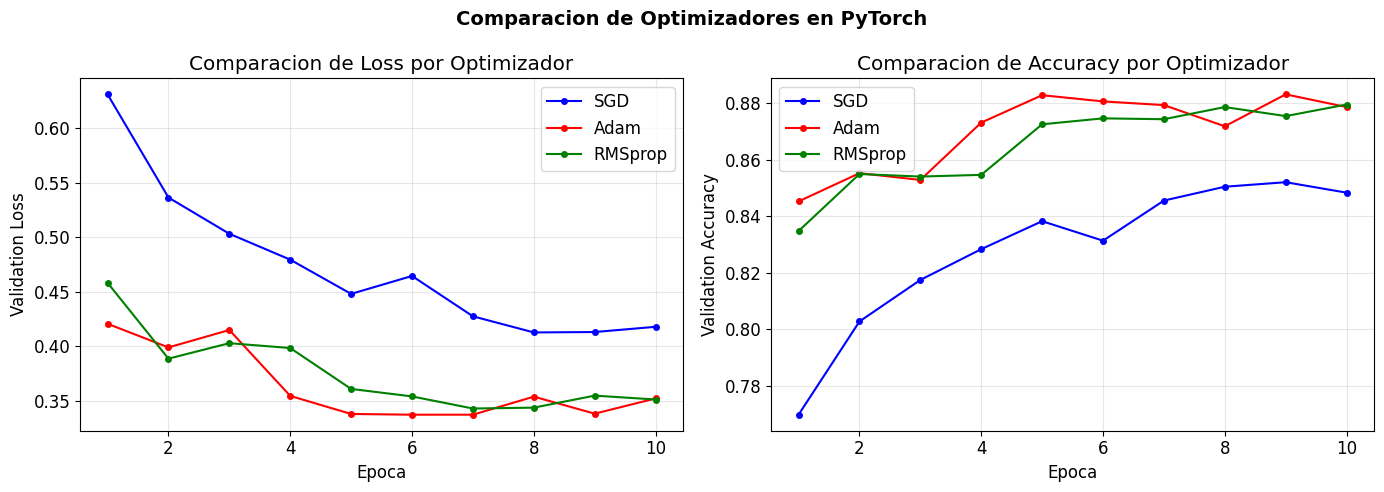

In [ ]:
# ========================================
# 6.3 Graficar comparacion de optimizadores
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = {'SGD': 'blue', 'Adam': 'red', 'RMSprop': 'green'}
epocas = range(1, NUM_EPOCHS_OPT + 1)

# Loss de validacion
for nombre, hist in resultados_opt.items():
    axes[0].plot(epocas, hist['val_loss'], '-o', color=colores[nombre],
                label=nombre, markersize=4)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Comparacion de Loss por Optimizador')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy de validacion
for nombre, hist in resultados_opt.items():
    axes[1].plot(epocas, hist['val_acc'], '-o', color=colores[nombre],
                label=nombre, markersize=4)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Comparacion de Accuracy por Optimizador')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparacion de Optimizadores en PyTorch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Tu respuesta - Experimento 6

**Pregunta:** ¿Los resultados de los optimizadores son consistentes con lo que viste en Keras? ¿Algun optimizador se comporto diferente?

*son consistentes con Keras: Adam y RMSprop logran la mejor precisión rápidamente (cerca del 88%), mientras que SGD es notablemente más lento y menos eficiente. Adam destaca por alcanzar el menor loss en menos tiempo, confirmando que los optimizadores adaptativos mantienen su superioridad en ambas librerías.*

---

### Experimento 7: Guardar y cargar modelos en PyTorch

En la Guia 04 aprendimos a guardar modelos en Keras (`.h5` o SavedModel). Ahora aprenderemos las convenciones de PyTorch para guardar y cargar modelos.

PyTorch ofrece dos formas principales:
1. **`state_dict()`** (recomendado): Guarda solo los pesos y parametros del modelo.
2. **Modelo completo**: Guarda la estructura + pesos usando `pickle` (no recomendado para produccion).

In [ ]:
# ========================================
# 7.1 Guardar el state_dict (RECOMENDADO)
# ========================================

# Guardar solo los pesos (state_dict)
ruta_modelo = 'modelo_fashion_mnist.pth'
torch.save(model.state_dict(), ruta_modelo)
print(f'Modelo guardado en: {ruta_modelo}')

# Verificar que se guardo
import os
tamano_archivo = os.path.getsize(ruta_modelo) / 1024  # En KB
print(f'Tamano del archivo: {tamano_archivo:.1f} KB')

# Ver que contiene el state_dict
state = model.state_dict()
print(f'\nClaves en el state_dict:')
for key, value in state.items():
    print(f'  {key}: {value.shape}')

Modelo guardado en: modelo_fashion_mnist.pth
Tamano del archivo: 430.4 KB

Claves en el state_dict:
  fc1.weight: torch.Size([128, 784])
  fc1.bias: torch.Size([128])
  fc2.weight: torch.Size([64, 128])
  fc2.bias: torch.Size([64])
  fc3.weight: torch.Size([10, 64])
  fc3.bias: torch.Size([10])


In [ ]:
# ========================================
# 7.2 Cargar el modelo
# ========================================

# Para cargar, primero necesitas crear la MISMA arquitectura
modelo_cargado = MiRed()  # Crear modelo con la misma estructura

# Cargar los pesos
modelo_cargado.load_state_dict(torch.load(ruta_modelo, weights_only=True))

# Mover a GPU
modelo_cargado = modelo_cargado.to(device)

# Poner en modo evaluacion
modelo_cargado.eval()

print('Modelo cargado exitosamente.')
print(f'Arquitectura: {modelo_cargado}')

Modelo cargado exitosamente.
Arquitectura: MiRed(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [ ]:
# ========================================
# 7.3 Verificar que las predicciones son identicas
# ========================================

# Obtener un batch de prueba
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

# Predicciones del modelo original
model.eval()
with torch.no_grad():
    pred_original = model(test_images)

# Predicciones del modelo cargado
with torch.no_grad():
    pred_cargado = modelo_cargado(test_images)

# Comparar
diferencia = torch.abs(pred_original - pred_cargado).max().item()
son_iguales = torch.equal(pred_original, pred_cargado)

print(f'¿Las predicciones son identicas? {son_iguales}')
print(f'Diferencia maxima: {diferencia}')

# Comparar algunas predicciones
print(f'\nPrimeras 5 predicciones (modelo original): {torch.argmax(pred_original[:5], dim=1).tolist()}')
print(f'Primeras 5 predicciones (modelo cargado):   {torch.argmax(pred_cargado[:5], dim=1).tolist()}')

¿Las predicciones son identicas? True
Diferencia maxima: 0.0

Primeras 5 predicciones (modelo original): [9, 2, 1, 1, 6]
Primeras 5 predicciones (modelo cargado):   [9, 2, 1, 1, 6]


In [ ]:
# ========================================
# 7.4 Guardar modelo completo vs state_dict
# ========================================

# Metodo 2: Guardar modelo completo (NO recomendado generalmente)
ruta_completo = 'modelo_completo.pth'
torch.save(model, ruta_completo)
tamano_completo = os.path.getsize(ruta_completo) / 1024

print('Comparacion de metodos de guardado:')
print(f'  state_dict():     {tamano_archivo:.1f} KB')
print(f'  Modelo completo:  {tamano_completo:.1f} KB')

# Para cargar modelo completo:
# modelo_completo = torch.load('modelo_completo.pth')

print('\n¿Por que se recomienda state_dict()?')
print('1. Es mas portable (no depende de la estructura exacta del codigo)')
print('2. Te da mas control al cargar (puedes modificar la arquitectura)')
print('3. Es la practica estandar en la comunidad de PyTorch')
print('4. Funciona mejor con diferentes versiones de PyTorch')

print('\nComparacion con Keras:')
print('  Keras:   model.save("modelo.h5")   -> Guarda todo (arquitectura + pesos)')
print('  PyTorch: torch.save(state_dict())  -> Guarda solo pesos (recomendado)')
print('  PyTorch: torch.save(model)         -> Guarda todo (no recomendado)')

# Guardar tambien checkpoint completo (util para continuar entrenamiento)
checkpoint = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': historial['train_loss'][-1],
    'val_acc': historial['val_acc'][-1]
}
torch.save(checkpoint, 'checkpoint.pth')
print('\nCheckpoint guardado (incluye estado del optimizador para continuar entrenamiento).')

Comparacion de metodos de guardado:
  state_dict():     430.4 KB
  Modelo completo:  431.4 KB

¿Por que se recomienda state_dict()?
1. Es mas portable (no depende de la estructura exacta del codigo)
2. Te da mas control al cargar (puedes modificar la arquitectura)
3. Es la practica estandar en la comunidad de PyTorch
4. Funciona mejor con diferentes versiones de PyTorch

Comparacion con Keras:
  Keras:   model.save("modelo.h5")   -> Guarda todo (arquitectura + pesos)
  PyTorch: torch.save(state_dict())  -> Guarda solo pesos (recomendado)
  PyTorch: torch.save(model)         -> Guarda todo (no recomendado)

Checkpoint guardado (incluye estado del optimizador para continuar entrenamiento).


### Tu respuesta - Experimento 7

**Pregunta:** ¿Cual es la diferencia entre guardar `state_dict()` vs guardar el modelo completo? ¿Cual es la practica recomendada en PyTorch?

*Guardar el state_dict() es la práctica recomendada porque solo almacena los pesos y sesgos del modelo, lo que lo hace más portátil, flexible ante cambios de arquitectura y compatible entre versiones de PyTorch. A diferencia de guardar el modelo completo, que depende de la estructura exacta de los archivos para recargarse, el state_dict() es más eficiente y ligero, ocupando en tu caso 430.4 KB frente a los 431.4 KB del archivo completo. Este método es el estándar de la comunidad porque separa los datos aprendidos de la definición del código, facilitando el intercambio y despliegue del modelo.*

---

### Experimento 8: Tabla resumen - Keras vs PyTorch lado a lado

Para consolidar lo aprendido, veamos una comparacion completa de codigo entre ambos frameworks para cada tarea comun.

#### 8.1 Definir un modelo

| Keras | PyTorch |
|-------|----------|
| ```model = Sequential([``` | ```class MiRed(nn.Module):``` |
| ```  Flatten(input_shape=(28,28)),``` | ```  def __init__(self):``` |
| ```  Dense(128, activation='relu'),``` | ```    super().__init__()``` |
| ```  Dense(64, activation='relu'),``` | ```    self.fc1 = nn.Linear(784, 128)``` |
| ```  Dense(10, activation='softmax')``` | ```    self.fc2 = nn.Linear(128, 64)``` |
| ```])``` | ```    self.fc3 = nn.Linear(64, 10)``` |
| | ```  def forward(self, x):``` |
| | ```    x = x.view(x.size(0), -1)``` |
| | ```    x = F.relu(self.fc1(x))``` |
| | ```    x = F.relu(self.fc2(x))``` |
| | ```    return self.fc3(x)``` |

#### 8.2 Compilar / Configurar

| Keras | PyTorch |
|-------|----------|
| ```model.compile(``` | ```criterion = nn.CrossEntropyLoss()``` |
| ```  optimizer='adam',``` | ```optimizer = optim.Adam(``` |
| ```  loss='sparse_categorical_crossentropy',``` | ```  model.parameters(), lr=0.001``` |
| ```  metrics=['accuracy']``` | ```)``` |
| ```)``` | |

#### 8.3 Entrenar

| Keras | PyTorch |
|-------|----------|
| ```history = model.fit(``` | ```for epoch in range(epochs):``` |
| ```  X_train, y_train,``` | ```  for X_batch, y_batch in loader:``` |
| ```  epochs=10,``` | ```    outputs = model(X_batch)``` |
| ```  batch_size=64,``` | ```    loss = criterion(outputs, y_batch)``` |
| ```  validation_data=(X_val, y_val)``` | ```    loss.backward()``` |
| ```)``` | ```    optimizer.step()``` |
| | ```    optimizer.zero_grad()``` |

#### 8.4 Evaluar

| Keras | PyTorch |
|-------|----------|
| ```loss, acc = model.evaluate(``` | ```model.eval()``` |
| ```  X_test, y_test``` | ```with torch.no_grad():``` |
| ```)``` | ```  outputs = model(X_test)``` |
| | ```  _, preds = outputs.max(1)``` |
| | ```  acc = (preds == y_test).float().mean()``` |

#### 8.5 Guardar y cargar

| Keras | PyTorch |
|-------|----------|
| ```model.save('modelo.h5')``` | ```torch.save(model.state_dict(), 'm.pth')``` |
| ```model = load_model('modelo.h5')``` | ```model = MiRed()``` |
| | ```model.load_state_dict(torch.load('m.pth'))``` |

#### 8.6 GPU

| Keras | PyTorch |
|-------|----------|
| Automatico (usa GPU si esta disponible) | Manual: `model.to(device)` |
| No necesitas mover datos | Datos: `tensor.to(device)` |

### Tu respuesta - Experimento 8

**Pregunta:** Despues de usar ambos frameworks, ¿cual prefieres y por que? ¿En que situaciones usarias cada uno?

Keras es ideal para prototipos rápidos por su sencillez y automatización, mientras que PyTorch es preferible para investigación y control total, ya que exige definir manualmente procesos como el forward pass y el manejo de la GPU. En resumen, usa Keras si buscas velocidad con model.fit() y PyTorch si necesitas personalizar la lógica interna o entender profundamente cómo fluyen los datos y gradientes en tu modelo.

---

## 5. Sintesis y reflexion

Has completado la transicion de Keras a PyTorch. Ahora es momento de reflexionar sobre lo aprendido.

### Tu respuesta - Sintesis 1

**Pregunta:** Resume las diferencias clave entre Keras y PyTorch en tus propias palabras.

La diferencia fundamental es que Keras prioriza la simplicidad y rapidez mediante la automatización de procesos como el entrenamiento (model.fit()) y el uso de la GPU. En cambio, PyTorch ofrece control total y transparencia, exigiendo que definas manualmente el flujo de datos (forward pass), la limpieza de gradientes (zero_grad()) y el movimiento de tensores al hardware. Mientras Keras es ideal para prototipos rápidos por su facilidad de uso, PyTorch es el estándar para investigación y personalización profunda de modelos.

### Tu respuesta - Sintesis 2

**Pregunta:** ¿Que ventajas tiene escribir el ciclo de entrenamiento manualmente vs usar `model.fit()`?

Escribir el ciclo de entrenamiento manualmente en PyTorch ofrece un control total y transparencia sobre cada paso del proceso, permitiendo manipular los datos, los gradientes y el hardware de forma precisa. A diferencia de la automatización de model.fit() en Keras, el enfoque manual facilita la depuración técnica, la implementación de arquitecturas personalizadas y la gestión específica de recursos como el movimiento de tensores a la GPU mediante .to(device). Esta flexibilidad es fundamental en la investigación y en proyectos complejos donde se requiere intervenir en la lógica interna, como limpiar gradientes con optimizer.zero_grad() o personalizar el forward pass.

---

## 6. Reto extra: CNN en PyTorch para CIFAR-10

En la Guia 05, implementaste una Red Neuronal Convolucional (CNN) en Keras. Ahora, como reto, vas a implementar una CNN en PyTorch para el dataset **CIFAR-10** (imagenes a color de 32x32 con 10 clases).

### Objetivo: Alcanzar mas del 75% de accuracy en el conjunto de prueba.

### Instrucciones:

1. **Cargar CIFAR-10** usando `torchvision.datasets.CIFAR10` con las transformaciones adecuadas.

2. **Definir la arquitectura CNN** con la siguiente estructura sugerida:
   - `Conv2d(3, 32, 3, padding=1)` + `BatchNorm2d(32)` + `ReLU` + `MaxPool2d(2, 2)`
   - `Conv2d(32, 64, 3, padding=1)` + `BatchNorm2d(64)` + `ReLU` + `MaxPool2d(2, 2)`
   - `Conv2d(64, 128, 3, padding=1)` + `BatchNorm2d(128)` + `ReLU` + `MaxPool2d(2, 2)`
   - `Flatten`
   - `Linear(128 * 4 * 4, 256)` + `ReLU` + `Dropout(0.5)`
   - `Linear(256, 10)`

3. **Entrenar** con Adam, lr=0.001, por al menos 20 epocas.

4. **Evaluar** en el conjunto de prueba y reportar el accuracy.

5. **Visualizar** las curvas de entrenamiento y la matriz de confusion.

### Tips:
- Las imagenes CIFAR-10 tienen 3 canales (RGB), a diferencia de Fashion-MNIST que tiene 1 canal.
- `BatchNorm2d` ayuda a estabilizar y acelerar el entrenamiento.
- `Dropout` en las capas fully-connected previene el sobreajuste.
- Usa `transforms.RandomHorizontalFlip()` y `transforms.RandomCrop(32, padding=4)` como data augmentation para mejorar resultados.

100%|██████████| 170M/170M [01:04<00:00, 2.64MB/s]


CIFAR-10 cargado:
  Entrenamiento: 50000 imagenes
  Prueba: 10000 imagenes
  Clases: ['Avion', 'Auto', 'Pajaro', 'Gato', 'Ciervo', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camion']


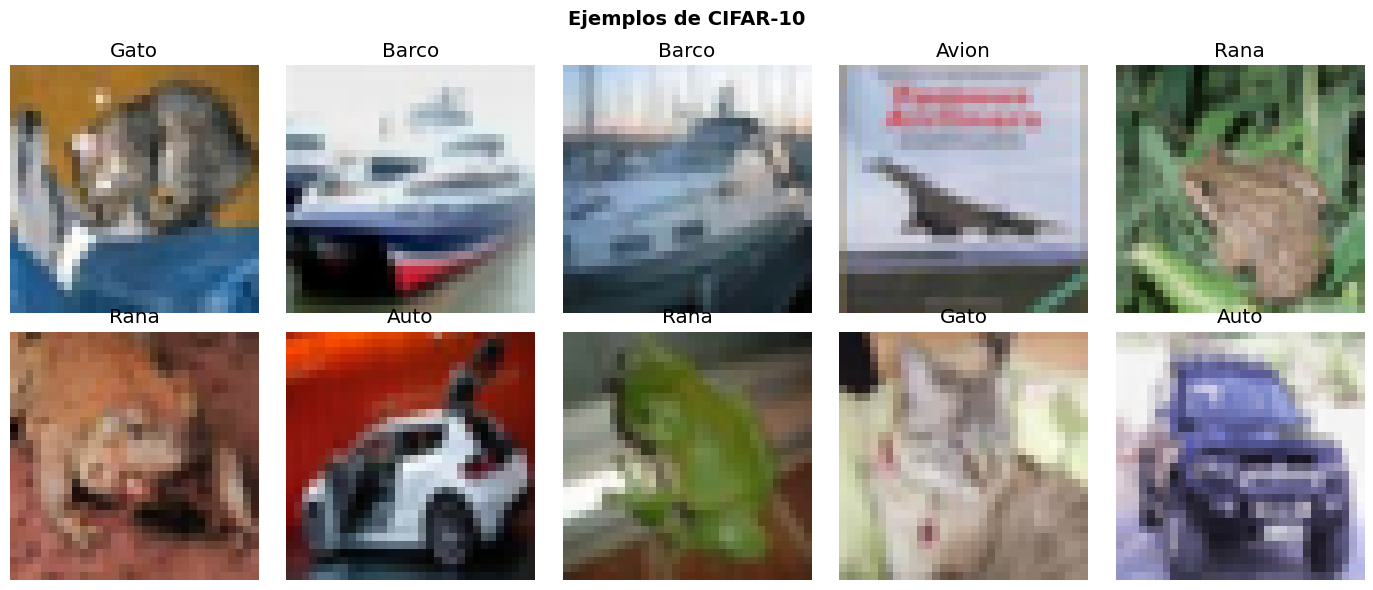

In [ ]:
# ========================================
# RETO: Implementa tu CNN para CIFAR-10 aqui
# ========================================

# Paso 1: Cargar CIFAR-10 con transformaciones
# Incluye data augmentation para entrenamiento

transform_train_cifar = transforms.Compose([
    transforms.RandomCrop(32, padding=4),      # Data augmentation
    transforms.RandomHorizontalFlip(),          # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # Media por canal de CIFAR-10
                         (0.2470, 0.2435, 0.2616))    # Std por canal de CIFAR-10
])

transform_test_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

cifar_train = datasets.CIFAR10(root='./data', train=True,
                                download=True, transform=transform_train_cifar)
cifar_test = datasets.CIFAR10(root='./data', train=False,
                               download=True, transform=transform_test_cifar)

cifar_train_loader = DataLoader(cifar_train, batch_size=128, shuffle=True, num_workers=2)
cifar_test_loader = DataLoader(cifar_test, batch_size=128, shuffle=False, num_workers=2)

cifar_classes = ['Avion', 'Auto', 'Pajaro', 'Gato', 'Ciervo',
                 'Perro', 'Rana', 'Caballo', 'Barco', 'Camion']

print(f'CIFAR-10 cargado:')
print(f'  Entrenamiento: {len(cifar_train)} imagenes')
print(f'  Prueba: {len(cifar_test)} imagenes')
print(f'  Clases: {cifar_classes}')

# Visualizar algunos ejemplos
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img, label = cifar_test[i]
    # Desnormalizar
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1) + \
          torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    img = img.clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())  # De CHW a HWC
    ax.set_title(cifar_classes[label])
    ax.axis('off')
plt.suptitle('Ejemplos de CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Paso 2: Definir la arquitectura CNN

class CNN_CIFAR(nn.Module):
    """
    Red Neuronal Convolucional para CIFAR-10.
    Incluye Conv2d, BatchNorm2d, MaxPool2d, Dropout.
    """
    def __init__(self):
        super(CNN_CIFAR, self).__init__()

        # Bloque convolucional 1
        # Entrada: [batch, 3, 32, 32]
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # -> [batch, 32, 32, 32]
        self.bn1 = nn.BatchNorm2d(32)
        # MaxPool2d(2,2) -> [batch, 32, 16, 16]

        # Bloque convolucional 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # -> [batch, 64, 16, 16]
        self.bn2 = nn.BatchNorm2d(64)
        # MaxPool2d(2,2) -> [batch, 64, 8, 8]

        # Bloque convolucional 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # -> [batch, 128, 8, 8]
        self.bn3 = nn.BatchNorm2d(128)
        # MaxPool2d(2,2) -> [batch, 128, 4, 4]

        # Capas fully connected
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

        # Pooling compartido
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        # Bloque 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Bloque 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Bloque 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Aplanar
        x = x.view(x.size(0), -1)  # [batch, 128*4*4]

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Instanciar modelo
modelo_cifar = CNN_CIFAR().to(device)
print('Arquitectura de la CNN para CIFAR-10:')
print(modelo_cifar)
print(f'\nParametros totales: {contar_parametros(modelo_cifar):,}')

Arquitectura de la CNN para CIFAR-10:
CNN_CIFAR(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

Parametros totales: 620,810


In [ ]:
# Paso 3: Entrenar la CNN

criterion_cifar = nn.CrossEntropyLoss()
optimizer_cifar = optim.Adam(modelo_cifar.parameters(), lr=0.001)

# Scheduler para reducir el learning rate
scheduler = optim.lr_scheduler.StepLR(optimizer_cifar, step_size=10, gamma=0.5)

NUM_EPOCHS_CIFAR = 25

historial_cifar = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print('Entrenando CNN en CIFAR-10...')
print('=' * 70)

mejor_acc = 0.0
tiempo_inicio_cifar = time.time()

for epoch in range(NUM_EPOCHS_CIFAR):
    # Entrenar
    train_loss, train_acc = entrenar_una_epoca(
        modelo_cifar, cifar_train_loader, criterion_cifar, optimizer_cifar, device
    )

    # Evaluar
    val_loss, val_acc = evaluar(
        modelo_cifar, cifar_test_loader, criterion_cifar, device
    )

    # Actualizar scheduler
    scheduler.step()

    # Guardar historial
    historial_cifar['train_loss'].append(train_loss)
    historial_cifar['train_acc'].append(train_acc)
    historial_cifar['val_loss'].append(val_loss)
    historial_cifar['val_acc'].append(val_acc)

    # Guardar mejor modelo
    if val_acc > mejor_acc:
        mejor_acc = val_acc
        torch.save(modelo_cifar.state_dict(), 'mejor_modelo_cifar.pth')

    if (epoch + 1) % 5 == 0:
        lr_actual = optimizer_cifar.param_groups[0]['lr']
        print(f'Epoca [{epoch+1:2d}/{NUM_EPOCHS_CIFAR}] '
              f'| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} '
              f'| LR: {lr_actual:.6f}')

tiempo_cifar = time.time() - tiempo_inicio_cifar
print('=' * 70)
print(f'Entrenamiento completado en {tiempo_cifar:.1f} segundos')
print(f'Mejor accuracy en test: {mejor_acc:.4f} ({mejor_acc*100:.2f}%)')
if mejor_acc > 0.75:
    print('\nObjetivo alcanzado: >75% accuracy')
else:
    print('\nIntenta entrenar por mas epocas o ajustar la arquitectura.')

Entrenando CNN en CIFAR-10...
Epoca [ 5/25] | Train Loss: 1.0079 | Train Acc: 0.6439 | Val Loss: 0.7994 | Val Acc: 0.7136 | LR: 0.001000
Epoca [10/25] | Train Loss: 0.8387 | Train Acc: 0.7103 | Val Loss: 0.7080 | Val Acc: 0.7531 | LR: 0.000500
Epoca [15/25] | Train Loss: 0.7129 | Train Acc: 0.7566 | Val Loss: 0.5958 | Val Acc: 0.7942 | LR: 0.000500
Epoca [20/25] | Train Loss: 0.6653 | Train Acc: 0.7723 | Val Loss: 0.5819 | Val Acc: 0.7997 | LR: 0.000250
Epoca [25/25] | Train Loss: 0.6075 | Train Acc: 0.7943 | Val Loss: 0.5368 | Val Acc: 0.8151 | LR: 0.000250
Entrenamiento completado en 527.4 segundos
Mejor accuracy en test: 0.8151 (81.51%)

Objetivo alcanzado: >75% accuracy


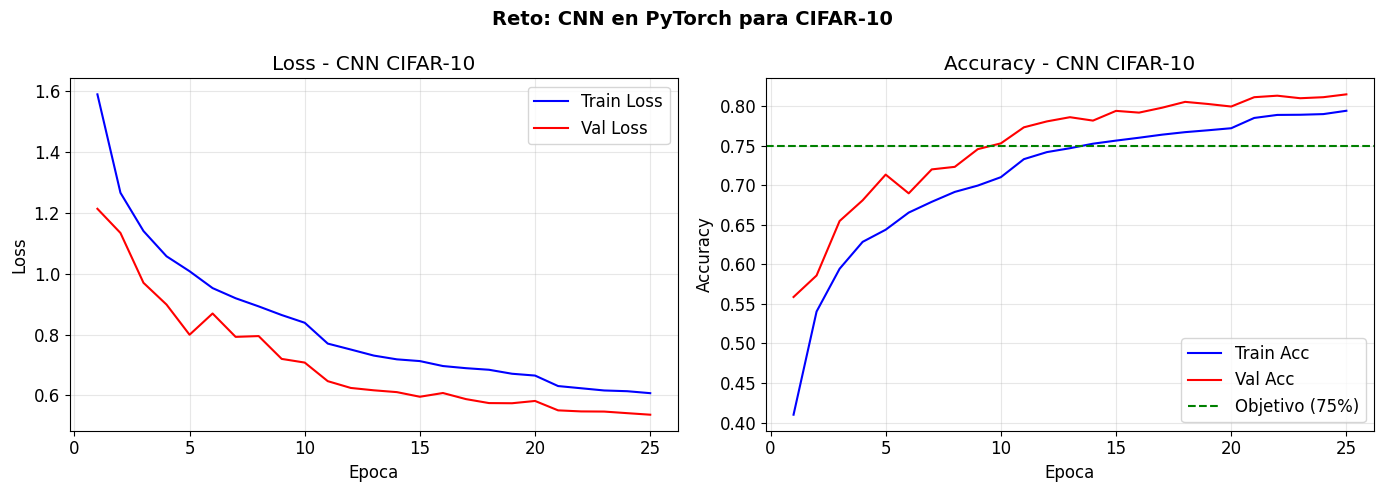

In [ ]:
# Paso 4: Visualizar resultados del reto

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas_cifar = range(1, NUM_EPOCHS_CIFAR + 1)

# Loss
axes[0].plot(epocas_cifar, historial_cifar['train_loss'], 'b-', label='Train Loss')
axes[0].plot(epocas_cifar, historial_cifar['val_loss'], 'r-', label='Val Loss')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss - CNN CIFAR-10')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epocas_cifar, historial_cifar['train_acc'], 'b-', label='Train Acc')
axes[1].plot(epocas_cifar, historial_cifar['val_acc'], 'r-', label='Val Acc')
axes[1].axhline(y=0.75, color='green', linestyle='--', label='Objetivo (75%)')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy - CNN CIFAR-10')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Reto: CNN en PyTorch para CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Accuracy final en CIFAR-10: 0.8151 (81.51%)


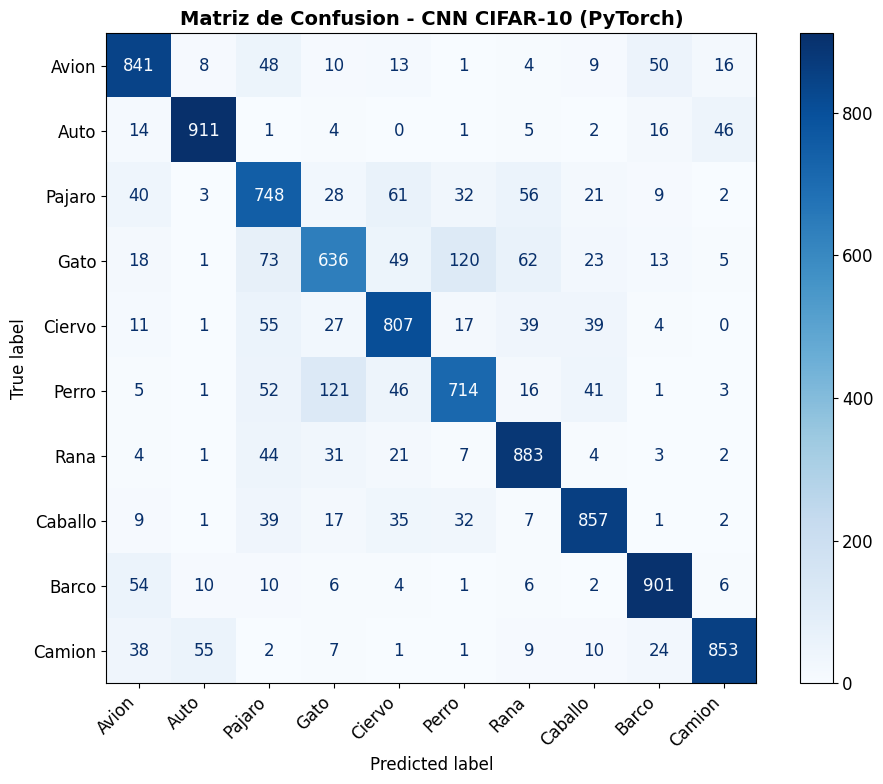


Reporte de clasificacion:
              precision    recall  f1-score   support

       Avion       0.81      0.84      0.83      1000
        Auto       0.92      0.91      0.91      1000
      Pajaro       0.70      0.75      0.72      1000
        Gato       0.72      0.64      0.67      1000
      Ciervo       0.78      0.81      0.79      1000
       Perro       0.77      0.71      0.74      1000
        Rana       0.81      0.88      0.85      1000
     Caballo       0.85      0.86      0.85      1000
       Barco       0.88      0.90      0.89      1000
      Camion       0.91      0.85      0.88      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



In [ ]:
# Paso 5: Matriz de confusion para CIFAR-10

# Cargar el mejor modelo
modelo_cifar.load_state_dict(torch.load('mejor_modelo_cifar.pth', weights_only=True))
modelo_cifar.eval()

preds_cifar = []
labels_cifar = []

with torch.no_grad():
    for images, labels in cifar_test_loader:
        images = images.to(device)
        outputs = modelo_cifar(images)
        _, predicted = torch.max(outputs, 1)
        preds_cifar.extend(predicted.cpu().numpy())
        labels_cifar.extend(labels.numpy())

preds_cifar = np.array(preds_cifar)
labels_cifar = np.array(labels_cifar)

# Accuracy final
acc_final = (preds_cifar == labels_cifar).mean()
print(f'Accuracy final en CIFAR-10: {acc_final:.4f} ({acc_final*100:.2f}%)')

# Matriz de confusion
cm_cifar = confusion_matrix(labels_cifar, preds_cifar)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cifar, display_labels=cifar_classes)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusion - CNN CIFAR-10 (PyTorch)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Reporte
print('\nReporte de clasificacion:')
print(classification_report(labels_cifar, preds_cifar, target_names=cifar_classes))

---

## 7. Referencias y recursos adicionales

### Documentacion oficial
- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html) - Documentacion oficial completa.
- [PyTorch Tutorials](https://pytorch.org/tutorials/) - Tutoriales oficiales paso a paso.
- [PyTorch Cheat Sheet](https://pytorch.org/tutorials/beginner/ptchg_cheatsheet.html) - Hoja de referencia rapida.

### Tutoriales recomendados
- [Deep Learning with PyTorch: A 60 Minute Blitz](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html) - Tutorial introductorio oficial.
- [What is torch.nn really?](https://pytorch.org/tutorials/beginner/nn_tutorial.html) - Entendiendo nn.Module a fondo.
- [Visualizing Models, Data, and Training with TensorBoard](https://pytorch.org/tutorials/intermediate/tensorboard_tutorial.html) - Visualizacion del entrenamiento.

### Libros
- Stevens, E., Antiga, L., & Viehmann, T. (2020). *Deep Learning with PyTorch*. Manning Publications.
- Subramanian, V. (2018). *Deep Learning with PyTorch*. Packt Publishing.

### Articulos de referencia
- Paszke, A., et al. (2019). "PyTorch: An Imperative Style, High-Performance Deep Learning Library". *Advances in Neural Information Processing Systems 32*.

### Comparaciones utiles
- [Keras vs PyTorch](https://pytorch.org/tutorials/beginner/pytorch_with_examples.html) - Ejemplos progresivos en PyTorch.

---

**Siguiente guia:** Guia 09 - Continuaremos trabajando con PyTorch para explorar arquitecturas mas avanzadas.

---

*Guia 08 de 14 | Electiva II - Deep Learning | Tecnologico de Antioquia | 2026-1*